## Dataset Column Info


- "timestamp" - timestamp field for grouping the data
- "cnt" - the count of a new bike shares
- "t1" - real temperature in C
- "t2" - temperature in C "feels like"
- "hum" - humidity in percentage
- "wind_speed" - wind speed in km/h
- "weather_code" - category of the weather
- "is_holiday" - *boolean field* - 1 holiday / 0 non holiday
- "is_weekend" - *boolean field* - 1 if the day is weekend

- "season" - category field meteorological seasons:

        0-spring
        
        1-summer;
        
        2-fall;
        
        3-winter.

- "weathe_code" category description:

      1 = Clear ; mostly clear but have some values with haze/fog/patches of fog/ fog in vicinity

      2 = scattered clouds / few clouds

      3 = Broken clouds

      4 = Cloudy

      7 = Rain/ light Rain shower/ Light rain

      10 = rain with thunderstorm
      
      26 = snowfall
      
      94 = Freezing Fog



# Module Loading & Data Reading

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

import warnings
warnings.filterwarnings('ignore')

In [7]:
df= pd.read_csv('/content/london_merged.csv')
df.head(2)

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0


# Data Cleaning

## Null Values

In [8]:
df.isnull().sum()

,0
timestamp,0
cnt,0
t1,0
t2,0
hum,0
wind_speed,0
weather_code,0
is_holiday,0
is_weekend,0
season,0


**0 Null Values**

## Duplicated Values

In [9]:
df.duplicated().sum()

np.int64(0)

**0 Duplicated Values**

## Data Types

In [10]:
df.info( )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     17414 non-null  object 
 1   cnt           17414 non-null  int64  
 2   t1            17414 non-null  float64
 3   t2            17414 non-null  float64
 4   hum           17414 non-null  float64
 5   wind_speed    17414 non-null  float64
 6   weather_code  17414 non-null  float64
 7   is_holiday    17414 non-null  float64
 8   is_weekend    17414 non-null  float64
 9   season        17414 non-null  float64
dtypes: float64(8), int64(1), object(1)
memory usage: 1.3+ MB


### Making Bolean Columns Integer

In [11]:
df[['weather_code','is_holiday','is_weekend','season']] = df[['weather_code','is_holiday','is_weekend','season']].astype('int64')


### Converting Timestamp into Datetime

In [12]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month
df['year'] = df['timestamp'].dt.year
df['weekday'] = df['timestamp'].dt.day_name()
df['date'] = df['timestamp'].dt.date
df['date'] = pd.to_datetime(df['date'])


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     17414 non-null  datetime64[ns]
 1   cnt           17414 non-null  int64         
 2   t1            17414 non-null  float64       
 3   t2            17414 non-null  float64       
 4   hum           17414 non-null  float64       
 5   wind_speed    17414 non-null  float64       
 6   weather_code  17414 non-null  int64         
 7   is_holiday    17414 non-null  int64         
 8   is_weekend    17414 non-null  int64         
 9   season        17414 non-null  int64         
 10  hour          17414 non-null  int32         
 11  day           17414 non-null  int32         
 12  month         17414 non-null  int32         
 13  year          17414 non-null  int32         
 14  weekday       17414 non-null  object        
 15  date          17414 non-null  dateti

In [14]:
df.head(2)

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season,hour,day,month,year,weekday,date
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3,0,1,3,0,4,1,2015,Sunday,2015-01-04
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1,0,1,3,1,4,1,2015,Sunday,2015-01-04


- **Converted Bolean Columns From Float Into Integer**

- **Converted Timestamp into Datetime**

- **Extracted Hour, Day, Month, Year, Weekday, and Date**

# Analysis

## Hourly Trend

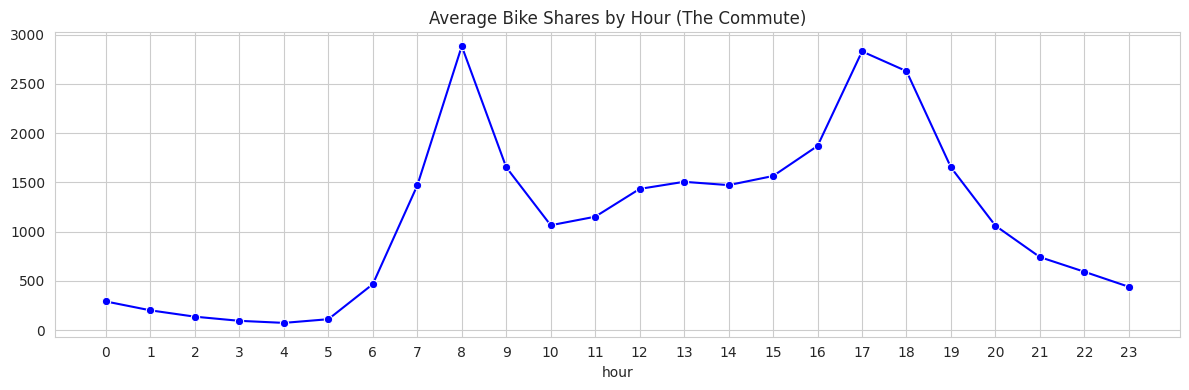

In [46]:
plt.figure(figsize=(12, 4))

# 1. Hourly Trend
hourly_data = df.groupby('hour')['cnt'].mean()
sns.lineplot(x=hourly_data.index, y=hourly_data.values, marker='o', color='blue')
plt.title("Average Bike Shares by Hour (The Commute)")
plt.xticks(range(0, 24)) # Show all 24 hours


plt.tight_layout()
plt.show()

- **Most Shares Accure 8am with average of 2900 Shares, With 5 and 6 Pm Comes next with 2830 and 2630**

**Double Peak: (8 AM and 5 PM) is the signature of a Commuter City**

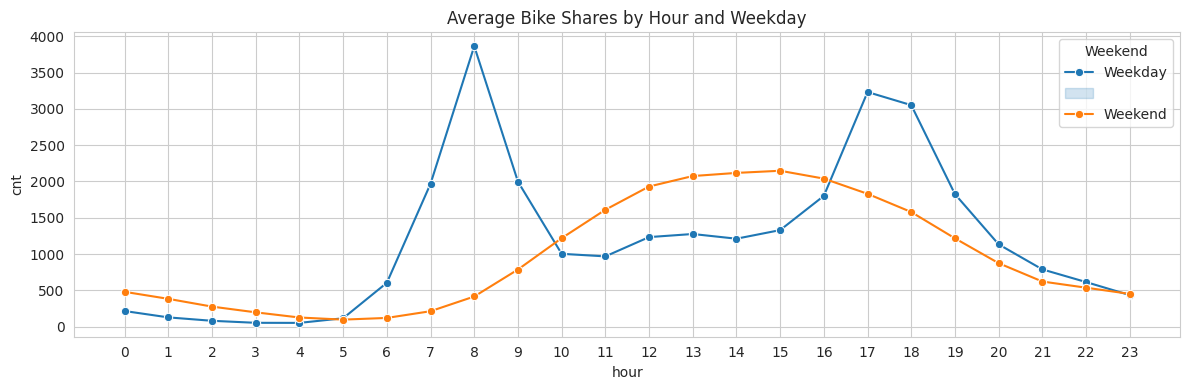

In [47]:
plt.figure(figsize=(12, 4))

# 2. Hourly Trend by Weekday
hourly_weekend_data = df.groupby(['hour','is_weekend'])['cnt'].mean().reset_index()
sns.lineplot(data=hourly_weekend_data,x='hour', y='cnt',hue='is_weekend', marker='o')
plt.legend(title='Weekend', labels=['Weekday',"", 'Weekend'])

plt.title("Average Bike Shares by Hour and Weekday")
plt.xticks(range(0, 24))


plt.tight_layout()
plt.show()

- **Weekend Curve Smooth and Peaks Around 12 to 4 pm**
- **Weekend Peak Differs From Weekday This Confirms That Most commuters are Workers**



---



## Monthly Trend

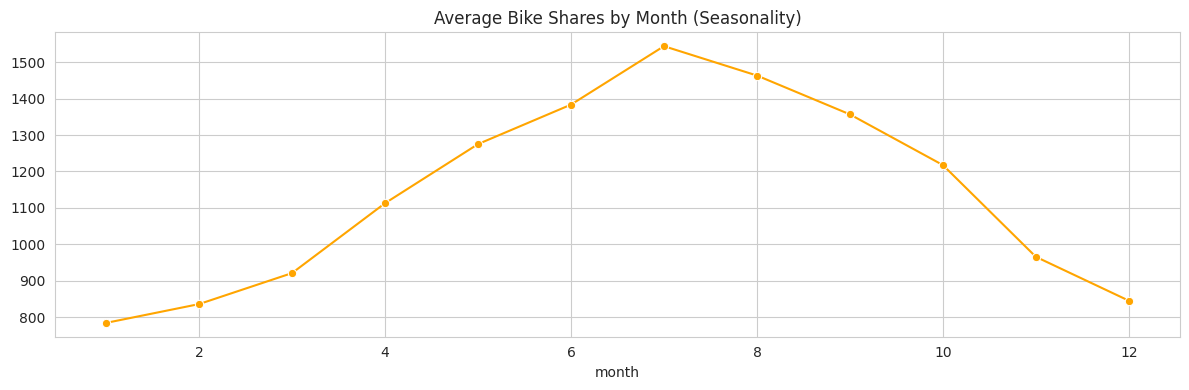

In [48]:
plt.figure(figsize=(12, 4))

# Monthly Trend
monthly_data = df.groupby('month')['cnt'].mean()
sns.lineplot(x=monthly_data.index, y=monthly_data.values, marker='o', color='orange')
plt.title("Average Bike Shares by Month (Seasonality)")

plt.tight_layout()
plt.show()

- **Highest Demand Appear In July With Average of 1550 Shares**
- **There Is Noticeable Gradual Decline Starting From August to Reach It's Lowest At January with only 785 Shares**



---



## Weather Effect On Bike Shares

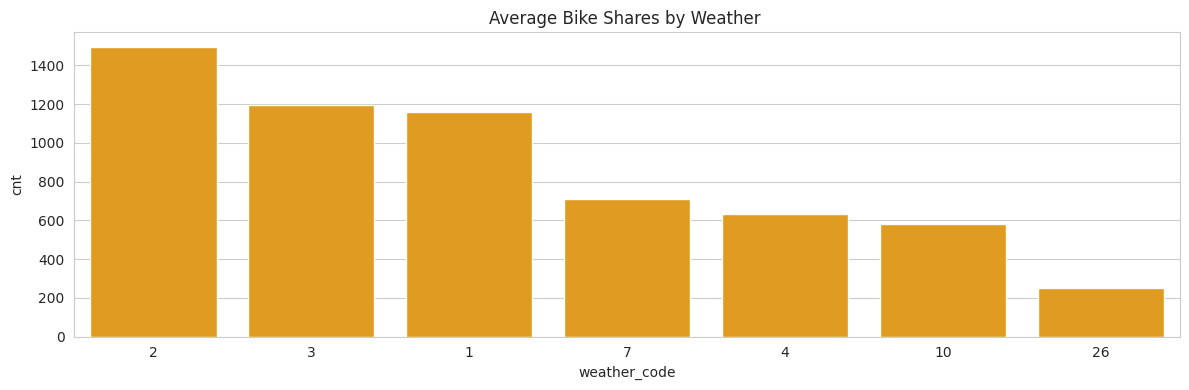

In [74]:
plt.figure(figsize=(12, 4))

# Weather Trend
weather_data = df.groupby('weather_code')['cnt'].mean().reset_index().sort_values(by='cnt',ascending=False)
weather_data['weather_code'] = weather_data['weather_code'].astype(str)
sns.barplot(weather_data, x='weather_code', y='cnt', color='orange')
plt.title("Average Bike Shares by Weather ")

plt.tight_layout()
plt.show()

      1 = Clear, 2 = scattered clouds, 3 = Broken clouds, 4 = Cloudy, 7 = Rain, 10 = rain with thunderstorm
      26 = snowfall, 94 = Freezing Fog

- Clear (1): 1,162 avg shares.

- Rain (7): 713 avg shares.

- **The Drop-off: Roughly 39%, it means 61% of people keep riding**

**Scattered Clouds (2) actually has higher demand (1,496) than Clear Skies (1) (1,162)**
- Clear Skies: often happen at night (2 AM), dragging the average down.
- Scattered Clouds is typical London daytime weather.



---



## Weekday vs Weekend

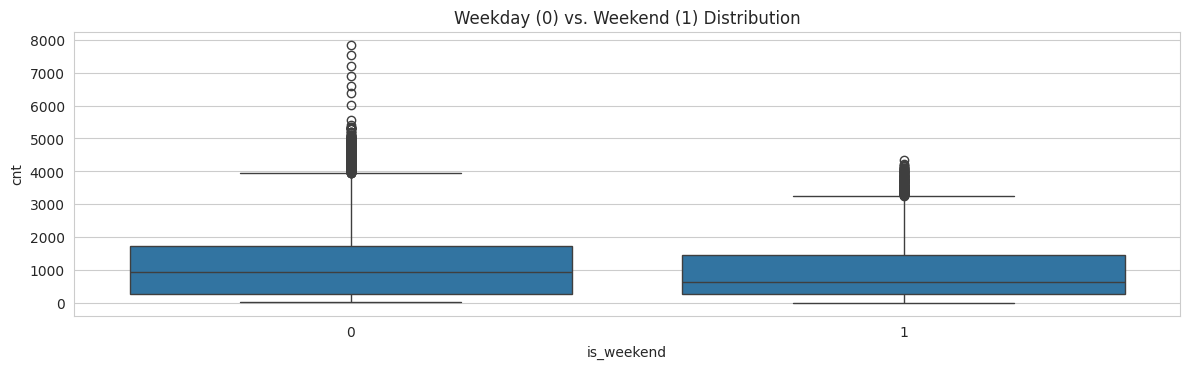

In [27]:
plt.figure(figsize=(12, 10))

# 3. Weekend vs Weekday
plt.subplot(3, 1, 3)
sns.boxplot(x='is_weekend', y='cnt', data=df)
plt.title("Weekday (0) vs. Weekend (1) Distribution")

plt.tight_layout()
plt.show()



---



## Temp

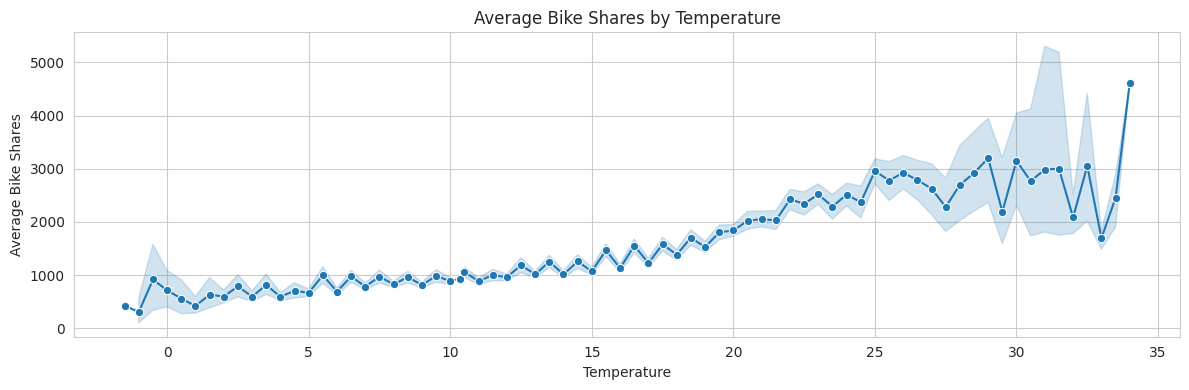

In [83]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=df,x='t1', y='cnt', marker='o',)
plt.title("Average Bike Shares by Temperature")
plt.xlabel("Temperature")
plt.ylabel("Average Bike Shares")
plt.tight_layout()
plt.show()

- < 5°C: Demand is dead (frozen).

- 20°C - 25°C: The "Goldilocks Zone." This is peak riding weather.



---



## Windspeed

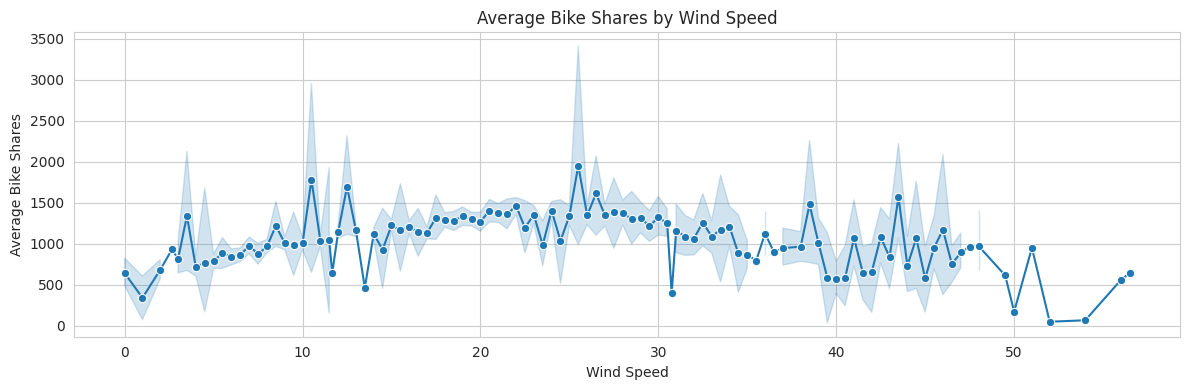

In [81]:
plt.figure(figsize=(12, 4))

sns.lineplot(data=df,x='wind_speed', y='cnt', marker='o')
plt.title("Average Bike Shares by Wind Speed")
plt.xlabel("Wind Speed")
plt.ylabel("Average Bike Shares")
plt.tight_layout()
plt.show()

- The Avg Shares By Windspeed chart is messier. It stays relatively flat until about 25-30 km/h, then gets chaotic.



---



## Humidity

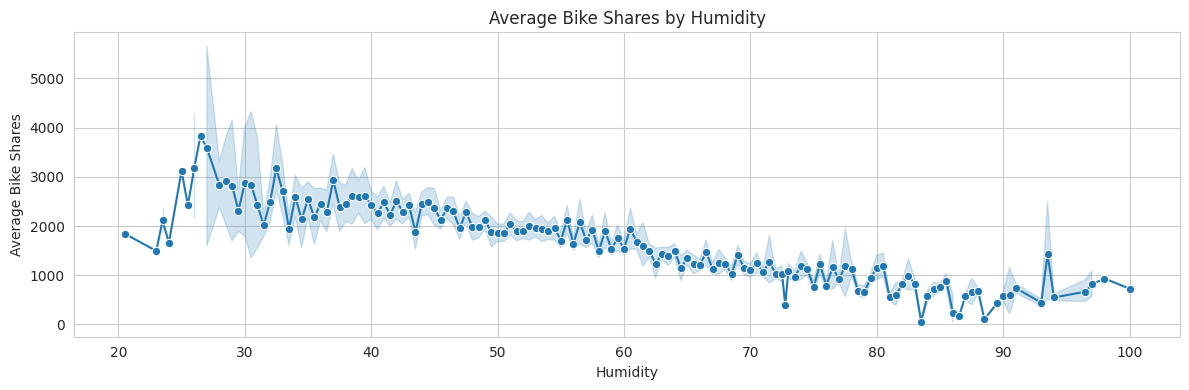

In [82]:
plt.figure(figsize=(12, 4))

sns.lineplot(data=df,x='hum', y='cnt', marker='o')
plt.title("Average Bike Shares by Humidity")
plt.xlabel("Humidity")
plt.ylabel("Average Bike Shares")
plt.tight_layout()
plt.show()

- **Low Humidity (< 40%**): Pleasant, dry air = **High Rides.**

- **High Humidity (> 80%)**: This usually signals rain or "sweaty" mugginess = **Low Rides.**



---



# Machine Learning

## Module Loading

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

## Data Prep

In [88]:
X = df[['t1', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'hour', 'month']]
y = df['cnt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Model Building

In [92]:
rfr = RandomForestRegressor()
rfr.fit(X_train, y_train)

RandomForestRegressor()

## Prediction

In [93]:
y_pred = rfr.predict(X_test)

In [96]:
pred_df = {'Actual': y_test, 'Predicted': y_pred}
pred_df = pd.DataFrame(pred_df)

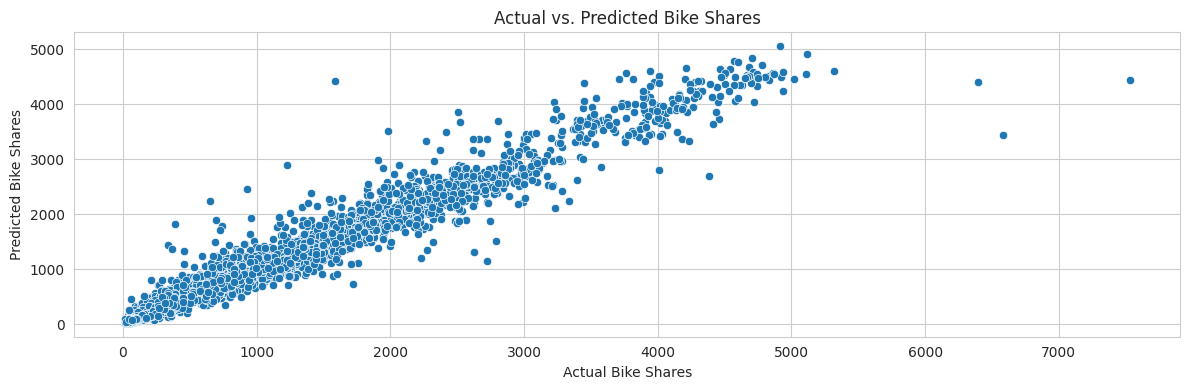

In [102]:
plt.figure(figsize=(12, 4))
sns.scatterplot(data=pred_df, x='Actual', y='Predicted')
plt.title("Actual vs. Predicted Bike Shares")
plt.xlabel("Actual Bike Shares")
plt.ylabel("Predicted Bike Shares")
plt.tight_layout()

## Model Accuracy

In [91]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.9512986716991166
MSE: 58356.02442141978


- **The Model captures 95% of the variance in bike demand**
- **MSE (58,356)** in perspective: sqrt{58,356} approx 241
This means the predictions are, on average, off by only ~241 bikes per hour



---



## Feature Importance

        Feature  Importance
6          hour    0.712014
0            t1    0.096513
5    is_weekend    0.078724
1           hum    0.042148
4    is_holiday    0.020672
3  weather_code    0.018039
2    wind_speed    0.016684
7         month    0.015207


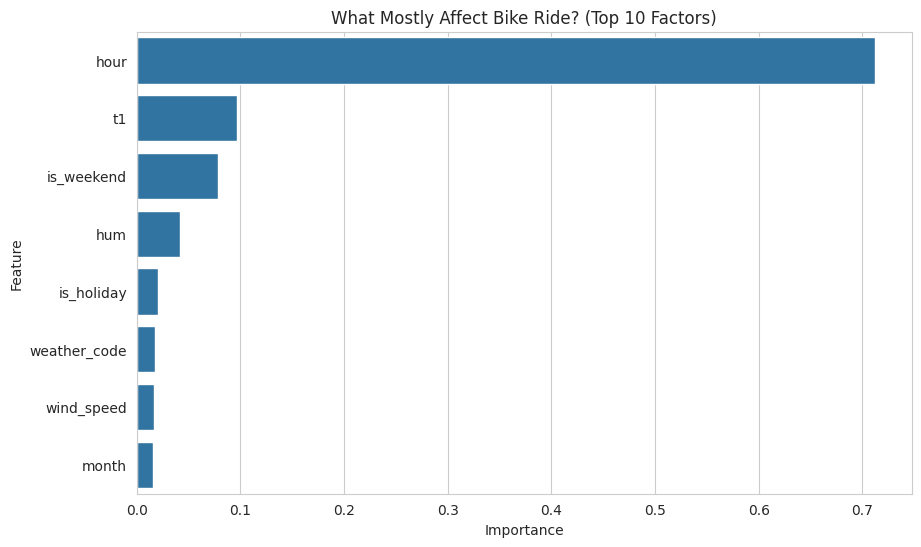

In [95]:
importances = rfr.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title("What Mostly Affect Bike Ride? (Top 10 Factors)")
plt.show()

- Hour (0.71): This feature alone accounts for 71% of model's intelligence.

The Business Meaning: It doesn't matter if it's raining, sunny, hot, or cold—if it is 8:00 AM on a Tuesday, people need to get to work. The "Commuter Routine" overrides almost everything else.



---



## Demand Simulator

In [105]:
def predict_demand(temp, humidity, wind_speed, hour, is_weekend,
                   month=7, is_holiday=0, weather_code=2):

    input_data = pd.DataFrame({
        't1': [temp],
        'hum': [humidity],
        'wind_speed': [wind_speed],
        'weather_code': [weather_code],
        'is_holiday': [is_holiday],
        'is_weekend': [is_weekend],
        'hour': [hour],
        'month': [month]
    })

    # 2. SAFETY STEP: Reorder columns to match X_train exactly
    feature_order = ['t1', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'hour', 'month']
    input_data = input_data[feature_order]

    # 3. Predict
    prediction = rfr.predict(input_data)[0]

    # 4. Print results
    print(f"--- PREDICTION ---")
    print(f"Time: {hour}:00 | Month: {month}")
    print(f"Weather: {temp}°C | Hum: {humidity}% | Wind: {wind_speed} km/h")
    print(f"🚲 PREDICTED DEMAND: {int(prediction)} bikes")
    print("-" * 30)

# --- TEST THE SIMULATOR ---

# Scenario 1: The "Perfect Commute"
# (25°C, Dry, 5 PM on a Tuesday in July)
predict_demand(temp=25, humidity=20, wind_speed=10, hour=17, is_weekend=0)

# Scenario 2: The "Miserable Night"
# (2°C, Wet, 3 AM on a Winter Tuesday)
# Notice we override the defaults for month and weather here
predict_demand(temp=2, humidity=90, wind_speed=40, hour=3, is_weekend=0,
               month=1, weather_code=7)

--- PREDICTION ---
Time: 17:00 | Month: 7
Weather: 25°C | Hum: 20% | Wind: 10 km/h
🚲 PREDICTED DEMAND: 4465 bikes
------------------------------
--- PREDICTION ---
Time: 3:00 | Month: 1
Weather: 2°C | Hum: 90% | Wind: 40 km/h
🚲 PREDICTED DEMAND: 32 bikes
------------------------------




---



# Executive Conclusion

1. **The Goal**

- The objective of this project was to predict bike-sharing demand in London to optimize fleet logistics. Using historical data from 2015-2017, we analyzed the impact of weather and time on ridership.

2. **Key Findings**

- **The Commuter Heartbeat:** The system is powered by workers. Distinct peaks at 8:00 AM and 5:00 PM confirm this is a transit utility, not just a tourist attraction.

- **The Weather Sensitivity:**

  - Temperature is the strongest driver of volume. Ridership increases linearly as temperature rises.

  - Rain causes a ~39% drop in demand, but 61% of users continue to ride, proving high service stickiness.

  - Seasonality: Demand hits rock bottom in December/January, making this the ideal window for heavy fleet maintenance.

3. **The Solution**

- **Algorithm**: Random Forest Regressor.
- **Performance**: Achieved an $R^2$ Score of 0.95, capturing 95% of the variance in demand.
- **Reliability**: The model successfully differentiates between high-demand scenarios (4,000+ bikes) and low-demand scenarios (less than 50 bikes) with high precision.

4. **Recommendations for Operations**

- **Dynamic Trucking**: Use the predict_demand() tool to pre-stock stations at 7:00 AM on days forecasted to be above 20°C.

- **Maintenance Scheduling**: Shift major repair work to January, where demand is ~50% lower than July.

- **Staffing**: Reduce staffing during "Heavy Rain" forecasts, as demand reliably drops by nearly 40%.



---



# Thanks
# Ahmed A. Elatwy.



---

